# 第8回 Python Seminar：タイタニック号の生存予測

配布された `train_titanic.csv` だけでモデルを0から学習し、`test_titanic.csv` 179件の `Survived` を予測します。評価指標は **F1スコア（生存=1が正例）** です。

このNotebookは、初心者が『どこを考えて変更するか』を追いやすいように、重要な設定を序盤へまとめています。外部データ・インターネット上の正解・LLMによる分類は使用しません。

## 1. 最初に確認するレギュレーション

- 使用データは、このフォルダの学習CSVとテストCSVだけです。
- 正式な評価指標はF1スコアです。PPTX画像内の `accuracy_score` より、更新された規約を優先します。
- 学習データを5分割し、前処理も各foldの学習部分だけで `fit` します。
- テストデータは最後の予測にだけ使い、モデル・特徴量・しきい値の選択には使いません。
- 提出候補は、XGBoost、Extra Trees、両者のsoft votingの3個です。
- すべて配布学習データから0から学習する公開可能なモデルです。

> **重要：** ここで表示するCV F1は学習データ内の見積もりです。正解がないテストデータのF1ではありません。

## 2. 全体の流れ

1. 設定を確認する
2. CSVの列・行数・欠損を確認する
3. 配布列から特徴量を作る
4. 5分割交差検証で、各行のOOF予測確率を作る
5. OOF予測だけでF1が高いしきい値とアンサンブル比率を選ぶ
6. 学習データ全体で再学習し、テストデータを予測する
7. 最大3個の提出CSVを保存・検査する

## 3. 人間が検討する場所（先に一覧）

| 検討項目 | このNotebookの初期値 | 主な変更場所 | 注意点 |
| --- | --- | --- | --- |
| 評価指標 | F1（正例=1） | `TARGET`, 評価関数 | 規約上F1は変更しない |
| 乱数seed | 8 | `SEED` | 比較中は固定する |
| 検証方法 | Stratified 5-fold | `N_SPLITS` | 前処理をfold外でfitしない |
| 前処理 | 数値=中央値、カテゴリ=最頻値+One-hot | `build_preprocessor` | テスト全体で補完値を作らない |
| 特徴量 | 敬称、家族人数、デッキ等 | `make_features` | 目的変数や外部正解を混ぜない |
| XGBoost | 深さ3のboosting | `XGB_PARAMS` | 深くしすぎると過学習しやすい |
| Extra Trees | 多数のランダム木 | `EXTRA_PARAMS` | XGBoostと異なる誤り方を狙う |
| 判定しきい値 | 0.20〜0.80を0.01刻み | `THRESHOLD_GRID` | テスト正解で調整しない |
| 混合比 | 0.00〜1.00を0.05刻み | `BLEND_WEIGHT_GRID` | OOF予測だけで決める |

まずは初期値のまま最後まで実行し、その後は**一度に1項目だけ**変更してCV F1とfold間のばらつきを比較してください。

## 3.1 はじめて機械学習を行う人向けの用語集

- **分類**：答えをいくつかのクラスから選ぶ問題です。今回は「死亡=0」「生存=1」の二択です。
- **回帰**：売上や気温のような連続した数値を予測する問題です。例にある `DummyRegressor` は回帰用なので、今回は使いません。
- **特徴量（X）**：予測の材料です。`Sex`、`Age`、`Pclass` などが該当します。
- **目的変数（y）**：モデルに当ててほしい答えです。今回は `Survived` です。
- **モデル**：特徴量と答えの関係を学び、新しい人の答えを予測する仕組みです。
- **学習（fit）**：学習データをモデルへ渡し、特徴量と答えの関係を覚えさせる処理です。
- **予測（predict / predict_proba）**：学習済みモデルへ新しい特徴量を渡す処理です。`predict_proba` は0/1ではなく、生存確率を返します。
- **前処理**：欠損値の補完や文字カテゴリの数値化など、モデルが読める形へデータを整える処理です。
- **ハイパーパラメータ**：木の本数や深さなど、人間が学習前に決める設定です。
- **交差検証（CV）**：学習データを何組かに分け、学習役と確認役を交代させて性能を測る方法です。
- **fold**：交差検証で分けた1組を指します。5-foldなら5組に分けます。
- **Pipeline**：前処理とモデルを1本につなぐ仕組みです。データリーク防止に役立ちます。
- **データリーク**：本来は予測時に知り得ない答えや検証・テスト側の情報が、学習へ混ざることです。

このNotebookでは、コード内でも `#` から始まるコメントを付けています。`#` より右側は説明文であり、Pythonの処理としては実行されません。


*〜 必要なライブラリと評価・学習用の道具を読み込みます 〜*

**このセルで行うこと**

- **入力**：なし。
- **処理**：CSV操作、グラフ、前処理、交差検証、F1計算、2種類の分類モデルに必要な道具を読み込みます。
- **出力**：画面にはほぼ何も表示しませんが、後のセルで使う名前が準備されます。

`import` は「別のファイルに用意された便利な道具を、このNotebookで使えるようにする」命令です。コメントには各道具の役割を書いています。


In [150]:
# Path: OSに依存しにくい方法で、CSVや出力先のパスを扱う道具
from pathlib import Path

# perf_counter: 学習にかかった時間を秒単位で測る道具
from time import perf_counter

# matplotlib: 棒グラフや混同行列を描くためのライブラリ
import matplotlib.pyplot as plt

# NumPy: 確率や0/1予測を配列として計算するライブラリ
import numpy as np

# pandas: CSVを読み、行と列を持つ表（DataFrame）として操作するライブラリ
import pandas as pd

# display: DataFrameをNotebook内で見やすい表として表示する道具
from IPython.display import display

# ColumnTransformer: 数値列と文字列で異なる前処理を行う道具
from sklearn.compose import ColumnTransformer

# ExtraTreesClassifier: 多数のランダムな決定木の結果をまとめる分類モデル
from sklearn.ensemble import ExtraTreesClassifier

# SimpleImputer: Ageなどの欠損値（空欄）を代表値で補う道具
from sklearn.impute import SimpleImputer

# 分類モデルをF1・Precision・Recall・混同行列で評価する道具
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

# StratifiedKFold: 生存率をそろえながら学習データを分割する道具
# cross_val_predict: 各行のOOF予測を作る道具
from sklearn.model_selection import StratifiedKFold, cross_val_predict

# Pipeline: 前処理とモデルを順番につなげ、データリークを防ぐ道具
from sklearn.pipeline import Pipeline

# OneHotEncoder: Sexなどの文字カテゴリを0/1の列へ変換する道具
from sklearn.preprocessing import OneHotEncoder

# XGBClassifier: 誤りを順番に改善する勾配ブースティングの分類モデル
from xgboost import XGBClassifier

# 表示する列を省略しすぎないよう、pandasの表示設定を変更
pd.set_option("display.max_columns", 100)

# グラフ全体へ見やすいデザインを適用
plt.style.use("seaborn-v0_8-whitegrid")


*〜 ファイル、seed、CV、探索範囲、モデルのハイパーパラメータを一か所にまとめます 〜*

**このセルで行うこと**

- **入力**：人間が決めた設定値。
- **処理**：データの場所、再現用seed、交差検証数、判定しきい値、モデル設定を変数へ保存します。
- **出力**：使用するseed・fold数・評価指標を表示します。

改善実験ではこのセルを主に変更します。比較を公平にするため、一度に複数項目を変えず、まず1項目だけ変えてください。


In [151]:
# ---------- 基本設定：実験の共通ルール ----------
# SEED: データ分割や木の作り方に使う乱数を固定し、同じ結果を再現する
SEED = 8

# TARGET: モデルが予測する正解列。今回は死亡=0、生存=1
TARGET = "Survived"

# ID_COLUMN: 乗客と予測を対応させる番号。モデルの予測材料には使わない
ID_COLUMN = "PassengerId"

# Pathで相対パスを指定すると、このNotebookと同じフォルダから読み込める
TRAIN_PATH = Path("train_titanic.csv")
TEST_PATH = Path("test_titanic.csv")
OUTPUT_DIR = Path("outputs")

# ---------- 評価と探索：人間が特に検討する設定 ----------
# N_SPLITS=5: 学習データを5組に分けて交差検証する
N_SPLITS = 5

# 生存確率を0/1へ変える境界を、0.20から0.80まで0.01刻みで比較する
THRESHOLD_GRID = np.round(np.arange(0.20, 0.801, 0.01), 2)

# アンサンブルで使うXGBoostの重みを、0%から100%まで5%刻みで比較する
BLEND_WEIGHT_GRID = np.round(np.arange(0.00, 1.001, 0.05), 2)

# ---------- モデル1：XGBoostのハイパーパラメータ ----------
XGB_PARAMS = {
    # n_estimators: 順番に作る決定木の本数
    "n_estimators": 600,
    # max_depth: 1本の木の最大深さ。大きいほど複雑な関係を学べるが過学習しやすい
    "max_depth": 3,
    # learning_rate: 1本ごとの修正量。小さくすると慎重に学習する
    "learning_rate": 0.025,
    # min_child_weight: 葉を分けるために必要なデータ量の目安
    "min_child_weight": 2,
    # subsample: 各木で使う学習行の割合。90%を使い、過学習を抑える
    "subsample": 0.90,
    # colsample_bytree: 各木で使う特徴量の割合
    "colsample_bytree": 0.90,
    # gamma: 木をさらに分割するために必要な改善量
    "gamma": 0.0,
    # reg_alpha / reg_lambda: モデルを複雑にしすぎないための正則化
    "reg_alpha": 0.02,
    "reg_lambda": 2.0,
    # binary:logistic: 0/1分類の生存確率を出力する設定
    "objective": "binary:logistic",
    # logloss: 学習中に確率予測の誤差を確認する指標
    "eval_metric": "logloss",
    # hist: 高速なヒストグラム方式で木を作る
    "tree_method": "hist",
    "random_state": SEED,
    # n_jobs=-1: 使用可能なCPUコアを使って計算する
    "n_jobs": -1,
}

# ---------- モデル2：Extra Treesのハイパーパラメータ ----------
EXTRA_PARAMS = {
    # n_estimators: 独立して作る決定木の本数
    "n_estimators": 800,
    # max_depth: 木の最大深さ
    "max_depth": 14,
    # min_samples_leaf: 末端の葉に最低2人を残し、細かすぎる分岐を抑える
    "min_samples_leaf": 2,
    # max_features="sqrt": 各分岐で特徴量の一部だけを候補にして木の多様性を増やす
    "max_features": "sqrt",
    # class_weight="balanced": 少ない生存者クラスを学習でやや重く扱う
    "class_weight": "balanced",
    "random_state": SEED,
    "n_jobs": -1,
}

print(f"seed={SEED}, CV={N_SPLITS} folds, metric=F1 (positive label=1)")


seed=8, CV=5 folds, metric=F1 (positive label=1)


## 4. データの読み込みと安全確認

`PassengerId` は提出結果を乗客へ対応させるキーとして保存しますが、番号の大小に意味を持たせないためモデル入力には使いません。

*〜 相対パスからCSVを読み、列・行数・ID・目的変数が規約どおりか検査します 〜*

**このセルで行うこと**

- **入力**：`train_titanic.csv` と `test_titanic.csv`。
- **処理**：CSVを表として読み、ファイル、列、行数、ID、0/1ラベルを `assert` で検査します。
- **出力**：表の大きさと学習データ先頭3行を表示します。

`assert 条件` は「条件が正しくなければ、その場で停止する安全装置」です。間違ったCSVのまま学習を進める事故を防ぎます。


In [152]:
# assert: 条件がFalseなら処理を止める安全確認
# まず、指定した場所に2つのCSVが実在するか確認する
assert TRAIN_PATH.exists(), f"学習CSVが見つかりません: {TRAIN_PATH}"
assert TEST_PATH.exists(), f"テストCSVが見つかりません: {TEST_PATH}"

# read_csv: CSVをpandasの表（DataFrame）として読み込む
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

# 予想している入力列を、順番も含めて一覧化する
feature_columns = [
    "PassengerId", "Pclass", "Name", "Sex", "Age",
    "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked",
]
expected_train_columns = ["PassengerId", "Survived", *feature_columns[1:]]

# 学習CSVにはSurvivedがあり、テストCSVにはないことを確認する
assert train.columns.tolist() == expected_train_columns
assert test.columns.tolist() == feature_columns

# レギュレーション記載の行数と一致するか確認する
assert len(train) == 712 and len(test) == 179

# PassengerIdが各CSV内で重複せず、学習とテストの間でも重複しないか確認する
assert train[ID_COLUMN].is_unique and test[ID_COLUMN].is_unique
assert set(train[ID_COLUMN]).isdisjoint(set(test[ID_COLUMN]))

# 学習の答えが0または1だけで、テストに答え列が混ざっていないか確認する
assert set(train[TARGET].dropna().unique()) <= {0, 1}
assert TARGET not in test.columns

# shape[0]は行数、shape[1]は列数
print(f"train: {train.shape[0]} rows x {train.shape[1]} columns")
print(f"test : {test.shape[0]} rows x {test.shape[1]} columns")
print("データ形式の安全確認: OK")

# head(3): 学習データの先頭3行を表示し、内容を目視確認する
display(train.head(3))


train: 712 rows x 12 columns
test : 179 rows x 11 columns
データ形式の安全確認: OK


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,503,0,3,"O'Sullivan, Miss. Bridget Mary",female,NaN,0,0,330909,7.6292,NaN,Q
1,465,0,3,"Maisner, Mr. Simon",male,NaN,0,0,A/S 2816,8.0500,NaN,S
2,199,1,3,"Madigan, Miss. Margaret ""Maggie""",female,NaN,0,0,370370,7.7500,NaN,Q


*〜 ラベルの偏りと欠損値を表にし、どんな前処理が必要か確認します 〜*

**このセルで行うこと**

- **入力**：読み込んだ `train` と `test`。
- **処理**：死亡/生存の件数・割合と、列ごとの空欄数を数えます。
- **出力**：ラベル分布表と欠損値表を表示します。

生存者が少なめなので、単純な正解率だけではなくF1を使います。欠損値がある列は、後のPipelineで補完します。


In [153]:
# value_counts: Survivedの0と1がそれぞれ何件あるか数える
label_summary = (
    train[TARGET]
    .value_counts()
    # sort_indexで0、1の順に並べる
    .sort_index()
    # 表の行名と件数列へ、わかりやすい名前を付ける
    .rename_axis(TARGET)
    .to_frame("count")
)

# 件数を学習データ全体の712件で割り、割合を計算する
label_summary["ratio"] = label_summary["count"] / len(train)

# isna: 空欄ならTrue、値があればFalseを返す
# Trueをsumすると、列ごとの欠損件数を数えられる
missing_summary = pd.DataFrame({
    "train_missing": train.drop(columns=TARGET).isna().sum(),
    "test_missing": test.isna().sum(),
})

# 学習・テストのどちらにも欠損がない列は、欠損表から省く
missing_summary = missing_summary.loc[missing_summary.sum(axis=1) > 0]

# ratioを61.66%のような読みやすい文字へ変えて表示する
label_summary_display = label_summary.copy()
label_summary_display["ratio"] = label_summary_display["ratio"].map("{:.2%}".format)
display(label_summary_display)

# Age、Cabin、Embarkedの欠損件数を表示する
display(missing_summary)


,count,ratio
Survived,,
0,439,61.66%
1,273,38.34%


,train_missing,test_missing
Age,146,31
Cabin,552,135
Embarked,2,0


*〜 ラベル分布と学習データの欠損数をグラフで確認します 〜*

**このセルで行うこと**

- **入力**：前セルで作った集計表。
- **処理**：左右2枚の棒グラフを作ります。
- **出力**：左に死亡/生存件数、右に欠損数上位5列を表示します。

表だけでなくグラフにすると、クラスの偏りや `Cabin` の欠損の多さを直感的に把握できます。


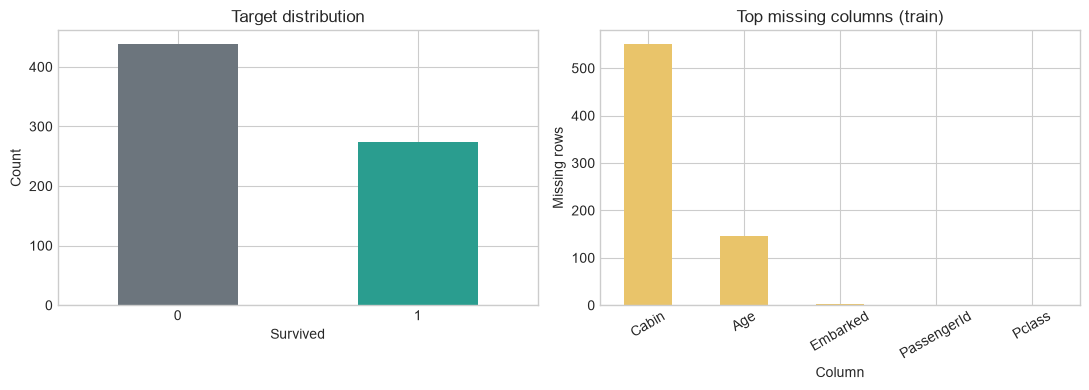

In [154]:
# subplots(1, 2): 横1行・縦2列のグラフ領域を作る
# figは図全体、axes[0]とaxes[1]は左右それぞれの描画場所
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# 左側：死亡0と生存1の件数を棒グラフにする
label_summary["count"].plot.bar(ax=axes[0], color=["#6c757d", "#2a9d8f"])
axes[0].set(title="Target distribution", xlabel="Survived", ylabel="Count")
axes[0].tick_params(axis="x", rotation=0)

# 右側：学習データで欠損が多い列を上位5つだけ表示する
train.drop(columns=TARGET).isna().sum().sort_values(ascending=False).head(5).plot.bar(
    ax=axes[1], color="#e9c46a"
)
axes[1].set(title="Top missing columns (train)", xlabel="Column", ylabel="Missing rows")
axes[1].tick_params(axis="x", rotation=30)

# 要素が重ならないよう配置を整えて表示する
plt.tight_layout()
plt.show()


## 5. 特徴量を作る

元の配布列に加え、次を作ります。すべて同じ行の情報だけから計算するため、テストの統計量や正解は使いません。

- `FamilySize`, `IsAlone`：同乗家族の規模
- `Title`：氏名の `Mr.` や `Mrs.` などの敬称
- `TicketPrefix`, `TicketLength`：チケット文字列の形式
- `CabinKnown`, `CabinDeck`, `CabinCount`：客室情報の有無・デッキ・客室数
- `FarePerPerson`：運賃を家族人数で割った値
- `AgeMissing`：年齢が欠損していたこと自体を表す0/1
- Extra Treesだけ `FamilyKey`, `TicketGroup`：同じ家族・チケットらしさを表すカテゴリ

`FamilyKey` と `TicketGroup` はOne-hot encoderが各学習fold内で学習します。未知カテゴリは安全に無視します。

### 特徴量で精度向上を狙った理由

決定木モデルは、渡されていない概念を自動的に理解するわけではありません。そこで、配布列から次のように「モデルが分岐に使いやすい形」を作りました。

| 工夫 | 精度向上を狙える理由 | リーク対策 |
| --- | --- | --- |
| `Title` | 氏名全文よりカテゴリ数が少なく、性別・年齢層・社会的属性の違いを木が捉えやすい | 各行の氏名だけから抽出 |
| `FamilySize`, `IsAlone` | `SibSp`と`Parch`を別々に見るだけでは分かりにくい「同乗家族の規模」を直接表す | 各行だけで計算 |
| `FarePerPerson` | 家族でまとめて支払われた可能性がある運賃を、1人当たりに近い尺度へ直す | 各行だけで計算 |
| `TicketPrefix`, `TicketLength` | チケット番号そのものを連続数値と誤解させず、文字形式の違いをカテゴリとして使える | 外部のチケット情報は使わない |
| `CabinKnown`, `CabinDeck`, `CabinCount` | 欠損の有無や客室位置らしき情報を、欠損の多い文字列から取り出せる | 各行だけで計算 |
| `AgeMissing` | 年齢の補完後にも「元は欠損だった」という情報を残せる | 正解を見ずに作成 |
| `FamilyKey`, `TicketGroup` | 同じ家族・同じチケットらしさをExtra Treesがカテゴリとして利用できる | One-hotのカテゴリ一覧は各学習foldだけで学習 |

XGBoostでは高カテゴリ数による過学習を抑えるため `FamilyKey` と `TicketGroup` を外し、Extra Treesでは木の多様性を生かすため追加しています。この**モデルごとの特徴量選択**も工夫の1つです。


*〜 配布された各行から、目的変数を見ずに特徴量を作る関数を定義します 〜*

**このセルで行うこと**

- **入力**：乗客データの表と、家族・チケットカテゴリを追加するかどうか。
- **処理**：氏名、家族人数、チケット、客室などから新しい予測材料を作ります。
- **出力**：このセルでは関数を定義するだけです。次のセルで関数を呼び出すと特徴量表が返ります。

`def` は処理をまとめた「自作の道具」を作る命令です。同じ処理を学習データとテストデータへ間違いなく適用できます。


In [155]:
def make_features(df: pd.DataFrame, include_group_categories: bool) -> pd.DataFrame:
    """1乗客の配布列だけから、モデル入力用の特徴量を作る関数。"""

    # まず、数値・カテゴリとしてそのまま使う基本7列をコピーする
    # copyを使うと、元のtrain/testを誤って書き換えない
    out = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]].copy()

    # 家族人数 = 本人1人 + 兄弟姉妹/配偶者 + 親/子ども
    out["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    # 一人で乗船していれば1、同乗家族がいれば0
    out["IsAlone"] = (out["FamilySize"] == 1).astype(int)

    # 家族全体の運賃らしき値を人数で割り、1人当たりの運賃を作る
    out["FarePerPerson"] = df["Fare"] / out["FamilySize"]

    # 氏名の文字数。長い氏名と短い氏名の違いを数値で表す
    out["NameLength"] = df["Name"].str.len()

    # 正規表現で「,」と「.」の間を抜き出し、MrやMissなどの敬称を作る
    # Mlle/MsはMiss、MmeはMrsと同じ意味の表記なのでまとめる
    out["Title"] = (
        df["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()
        .replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    )

    # チケット番号から数字と記号を除き、文字の接頭辞だけを取り出す
    # 文字が残らない場合はNUMERICというカテゴリにする
    out["TicketPrefix"] = (
        df["Ticket"].astype(str)
        .str.replace(r"\d", "", regex=True)
        .str.replace(r"[^A-Za-z]", "", regex=True)
        .str.upper()
        .replace("", "NUMERIC")
    )

    # チケット文字列の長さを数値特徴量にする
    out["TicketLength"] = df["Ticket"].astype(str).str.len()

    # 客室番号が記録されていれば1、欠損なら0
    out["CabinKnown"] = df["Cabin"].notna().astype(int)

    # 客室番号の最初の文字をデッキとして使い、欠損はMissingにする
    out["CabinDeck"] = df["Cabin"].str[0].fillna("Missing")

    # 空白で複数の客室番号が書かれている場合、その個数を数える
    out["CabinCount"] = df["Cabin"].fillna("").map(
        lambda value: 0 if value == "" else len(value.split())
    )

    # 年齢の値だけでなく「年齢が欠損していた」という情報も0/1で残す
    out["AgeMissing"] = df["Age"].isna().astype(int)

    # Extra Treesでは、同じ家族・同じチケットらしさを表すカテゴリも使う
    if include_group_categories:
        # 氏名のカンマより前を姓として取り出し、家族人数と結合する
        surname = df["Name"].str.split(",", n=1).str[0].str.strip()
        out["FamilyKey"] = surname + "_" + out["FamilySize"].astype(str)

        # チケットの空白と大文字小文字の違いをそろえ、グループ名として使う
        out["TicketGroup"] = (
            df["Ticket"].astype(str).str.replace(r"\s+", "", regex=True).str.upper()
        )

    # 作成した特徴量表を、関数の呼び出し元へ返す
    return out


*〜 XGBoost用とExtra Trees用の特徴量表を作り、列数を確認します 〜*

**このセルで行うこと**

- **入力**：`train`、`test`、前セルの `make_features` 関数。
- **処理**：答え `Survived` を `y`、予測材料を `X` に分け、2モデル用の特徴量を作ります。
- **出力**：特徴量表の行列サイズと、各列のデータ型を表示します。

`X` は予測材料、`y` は正解という機械学習でよく使われる名前です。`PassengerId` は照合用なので `X` には入りません。


In [156]:
# 学習データから答えSurvivedだけを外し、元の予測材料を作る
raw_train_features = train.drop(columns=TARGET)

# y: モデルに学習させる正解。0=死亡、1=生存
y = train[TARGET].astype(int)

# XGBoostには、比較的少数で一般化しやすい18特徴量を使う
X_xgb = make_features(raw_train_features, include_group_categories=False)

# Extra Treesには、家族・チケットカテゴリを加えた20特徴量を使う
X_extra = make_features(raw_train_features, include_group_categories=True)

# テストにも学習データと完全に同じ特徴量作成を行う
X_test_xgb = make_features(test, include_group_categories=False)
X_test_extra = make_features(test, include_group_categories=True)

# 学習用とテスト用の列名・順番が一致することを確認する
assert X_xgb.columns.equals(X_test_xgb.columns)
assert X_extra.columns.equals(X_test_extra.columns)

# PassengerIdや答えSurvivedが予測材料へ混ざっていないことを確認する
assert ID_COLUMN not in X_xgb.columns and TARGET not in X_xgb.columns

# shapeは（行数, 列数）を表す
print(f"XGBoost features   : {X_xgb.shape}")
print(f"Extra Trees features: {X_extra.shape}")

# dtypeはデータ型。float/intは数値、strはカテゴリとして処理する
display(pd.DataFrame({
    "XGBoost dtype": X_xgb.dtypes.astype(str),
    "Extra Trees dtype": X_extra.dtypes.astype(str),
}))


XGBoost features   : (712, 18)
Extra Trees features: (712, 20)


,XGBoost dtype,Extra Trees dtype
Age,float64,float64
AgeMissing,int64,int64
CabinCount,int64,int64
CabinDeck,str,str
CabinKnown,int64,int64
Embarked,str,str
FamilyKey,NaN,str
FamilySize,int64,int64
Fare,float64,float64
FarePerPerson,float64,float64


## 6. 前処理とモデル

`Pipeline` の中に前処理を入れることがデータリーク対策の中心です。CVの各foldで、中央値・最頻値・One-hotのカテゴリ一覧が学習部分だけから作られます。

- **One-hot encoding**：カテゴリを0/1の列へ変換します。
- **ブースティング**：前の木の誤りを次の木で順番に補う方法です。XGBoostが該当します。
- **アンサンブル学習**：複数モデルの予測を組み合わせる方法です。後でsoft votingを行います。

### 前処理とは何をすることか

前処理とは、CSVを読み込んだ直後のデータを、モデルが安全に学習できる形へ整える作業です。今回のCSVには、`Age`のような数値、`Sex`のような文字、空欄、カテゴリが混在しています。XGBoostやExtra Treesへそのまま渡すのではなく、次の順番で変換します。

```text
元の特徴量
  ├─ 数値列 ─────→ 欠損を中央値で補う ───────────┐
  └─ カテゴリ列 ─→ 欠損を最頻値で補う → One-hot化 ─┤
                                                    ↓
                                         1つの数値表へ結合
                                                    ↓
                                                分類モデル
```

#### 1. 数値列の前処理

`Age`、`Fare`、`FamilySize`などは数値列です。空欄を扱えない処理があるため、`SimpleImputer(strategy="median")` で**学習foldの中央値**を入れます。

例として、学習foldの年齢が `[18, 28, 欠損, 40]` なら中央値は28です。欠損を28へ置き換えます。平均値より中央値を使うと、非常に高い値や低い値の影響を受けにくい利点があります。さらに `add_indicator=True` により、「元は欠損だった」ことを示す0/1列も追加します。

#### 2. カテゴリ列の欠損補完

`Sex`、`Embarked`、`Title`、`CabinDeck`などは、数値の大小ではなく種類を表すカテゴリ列です。空欄は `SimpleImputer(strategy="most_frequent")` で、**学習fold内で最も多かったカテゴリ**へ置き換えます。

#### 3. One-hot encoding

モデルは `female`、`male`、`S`、`C`、`Q`といった文字を、そのままでは計算に使えません。One-hot encodingは、**カテゴリ1種類につき1本の0/1列を作る方法**です。

元のデータが次のような場合を考えます。

| 乗客 | `Sex` | `Embarked` |
| --- | --- | --- |
| A | female | S |
| B | male | C |
| C | female | Q |

One-hot encoding後は、次の数値表になります。

| 乗客 | `Sex_female` | `Sex_male` | `Embarked_C` | `Embarked_Q` | `Embarked_S` |
| --- | ---: | ---: | ---: | ---: | ---: |
| A | 1 | 0 | 0 | 0 | 1 |
| B | 0 | 1 | 1 | 0 | 0 |
| C | 1 | 0 | 0 | 1 | 0 |

乗客Aは女性なので `Sex_female=1`、男性ではないので `Sex_male=0` です。乗船港はSなので `Embarked_S=1`、CとQは0になります。この0/1は生存ラベルではなく、**そのカテゴリに当てはまるかどうか**だけを表します。

カテゴリへ単純に `C=0, Q=1, S=2` と番号を付けると、モデルが「SはQより大きい」「CからSまでの距離は2」のような、実際には存在しない順序や距離として解釈する可能性があります。One-hot encodingなら、C・Q・Sを対等な別カテゴリとして表現できます。

#### 4. このNotebookのOne-hot encoding設定

- `handle_unknown="ignore"`：学習foldになかったカテゴリがvalidationやtestに現れても停止しません。そのカテゴリに対応する既存列をすべて0として処理します。
- `min_frequency=2`：学習foldで1回しか現れない非常に珍しいカテゴリを「少数カテゴリ」としてまとめます。列数と過学習を抑える狙いがあります。
- One-hotの列一覧は**各foldの学習部分だけ**で作ります。validationやtestを見て列を先に作らないため、データリークを防げます。

#### 5. `fit` と `transform` の違い

- **fit**：学習foldから中央値、最頻値、存在するカテゴリ一覧を覚えます。
- **transform**：fitで覚えたルールを使って、学習fold・validation・testを数値表へ変換します。

validationやtestに対してもう一度fitすると、そのデータの情報を前処理へ取り込んでしまいます。このNotebookでは前処理とモデルを `Pipeline` へまとめているため、交差検証のたびに学習foldだけでfitし、validationにはtransformだけを行います。

#### 6. 標準化を行っていない理由

線形モデルや距離を使うモデルでは、年齢と運賃の単位をそろえる標準化が重要です。一方、今回のXGBoostとExtra Treesは「ある値より大きいか、小さいか」で分岐する決定木モデルです。値の単位を変えても並び順は変わらないため、標準化の必要性が比較的小さく、このNotebookでは省略しています。

### この3モデルを選んだ理由

| 提出候補 | このNotebookでの役割 | 選んだ理由 | 過学習を抑える設定 |
| --- | --- | --- | --- |
| **XGBoost** | 主力の単一モデル | 表形式データに強く、決定木を順番に追加して前の木の誤りを改善できます。年齢・運賃・客室等級などの非線形な関係や、性別×敬称のような組み合わせを学習できます。生存確率を出せるため、F1用しきい値の調整にも向きます。 | 深さ3、低い学習率、行・列のサンプリング、L1/L2正則化 |
| **Extra Trees** | XGBoostと異なる誤り方をする単一モデル | 多数の木を強くランダム化して平均するため、1本の木の偶然やばらつきを抑えられます。XGBoostとは「順番に誤りを直すboosting」と「独立した木を平均する方法」という違いがあり、アンサンブルの相手として多様性を作れます。 | 葉に最低2件、深さ14、各分岐で特徴量の一部だけを使用、クラス重み |
| **Soft voting** | 2モデルを組み合わせる3個目の提出候補 | XGBoostとExtra Treesの生存確率を平均すると、一方だけの過信や誤りを弱められる可能性があります。712件と小さいデータでは、複雑なstackingより仕組みが単純で過学習リスクを管理しやすい方法です。 | 重みとしきい値をテストではなくOOF予測だけで決定 |

今回の学習データ内OOF F1は、XGBoostが `0.7958`、Extra Treesが `0.7795`、soft votingが `0.8021` でした。Extra Trees単体はXGBoostより低いものの、予測の違いを混ぜたsoft votingが最も高かったため、**単体性能だけでなくモデル間の多様性**も選定理由にしています。これらは未知のテスト正解ではなく、学習データ内だけの比較結果です。

### 前処理・ハイパーパラメータで行った精度向上策

- 数値は中央値、カテゴリは最頻値で補完し、欠損で行を捨てずに712件を活用しました。
- One-hot encodingの `min_frequency=2` で、1回しか現れないカテゴリをまとめて過学習を抑えました。
- `handle_unknown="ignore"` により、検証・テストで初登場したカテゴリでも安定して予測できます。
- XGBoostは浅い木と低い学習率、サンプリング、正則化を組み合わせました。
- Extra Treesは木を800本平均し、`min_samples_leaf=2` と `max_features="sqrt"` で個々の木の過学習と相関を抑えました。
- `class_weight="balanced"` で、件数が少ない生存クラスをExtra Treesの学習で軽視しにくくしました。


*〜 数値とカテゴリの前処理、および2種類のモデルをPipelineとして組み立てます 〜*

**このセルで行うこと**

- **入力**：特徴量表と序盤で決めたハイパーパラメータ。
- **処理**：数値の欠損補完、文字の欠損補完・One-hot化、分類モデルを1本のPipelineへつなぎます。
- **出力**：Pipelineを作る3つの関数を定義します。

ここでまだ学習は始まりません。設計図を作っておき、交差検証の各foldで同じ設計図から新しいPipelineを作ります。


In [157]:
def build_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    """数値列とカテゴリ列に、それぞれ必要な前処理を作る。"""

    # number型を数値列、それ以外を文字カテゴリ列として自動的に分ける
    numeric_columns = X.select_dtypes(include="number").columns.tolist()
    categorical_columns = X.select_dtypes(exclude="number").columns.tolist()

    # 数値の欠損を、そのfoldの学習部分の中央値で補う
    # add_indicator=Trueにより、欠損だったことを示す0/1列も追加する
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ])

    # 文字の欠損を最頻値で補い、One-hot encodingで0/1列へ変換する
    # handle_unknown="ignore"により、検証・テストで初登場したカテゴリでも停止しない
    # min_frequency=2により、学習部分で1回しか出ないカテゴリをまとめる
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
    ])

    # 数値列とカテゴリ列へ別々のPipelineを適用し、最後に横へ結合する
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ])


def build_xgb_pipeline(X: pd.DataFrame) -> Pipeline:
    """前処理の後にXGBoostを実行するPipelineを作る。"""
    return Pipeline([
        ("preprocess", build_preprocessor(X)),
        # XGBClassifier: 木を順番に追加し、前の木の誤りを改善する分類モデル
        ("model", XGBClassifier(**XGB_PARAMS)),
    ])


def build_extra_pipeline(X: pd.DataFrame) -> Pipeline:
    """前処理の後にExtra Treesを実行するPipelineを作る。"""
    return Pipeline([
        ("preprocess", build_preprocessor(X)),
        # ExtraTreesClassifier: ランダム性の高い多数の木を平均する分類モデル
        ("model", ExtraTreesClassifier(**EXTRA_PARAMS)),
    ])


## 7. 5分割交差検証でOOF予測を作る

OOF（out-of-fold）予測とは、各乗客を、その乗客を学習に使っていないモデルで予測した値です。通常の学習データへの予測より、未知データに近い性能を見積もれます。`StratifiedKFold` で各foldの生存率をほぼ同じにします。

### 交差検証で行った精度向上・信頼性向上策

- `StratifiedKFold` により、各foldの死亡・生存割合を近づけました。生存者が少なめのデータでも、極端な分割になりにくくなります。
- 1回のtrain/validation分割だけで決めず、全5foldを交代で検証することで、偶然の分割に依存しにくい比較を行いました。
- 補完値とOne-hotカテゴリを `Pipeline` の中で学習させ、各foldの検証側情報が前処理へ漏れないようにしました。
- 2モデルで同じfoldを使い、分割条件の違いではなくモデルの違いを比較できるようにしました。

これは直接モデルを強くするだけでなく、**本当に未知データで良い可能性が高い設定を選ぶ**ための工夫です。


*〜 同じ5分割を2モデルで共有し、各学習行のOOF生存確率を計算します 〜*

**このセルで行うこと**

- **入力**：特徴量 `X`、正解 `y`、Pipeline、5分割設定。
- **処理**：5回の「4組で学習・残り1組を予測」を繰り返し、全712行のOOF生存確率を作ります。
- **出力**：2モデル分の確率配列と、処理時間を表示します。

OOF予測では、その人自身を学習に使ったモデルでその人を評価しません。学習済みデータをそのまま採点するより、未知データに近い確認になります。


In [158]:
# StratifiedKFold: 各foldの死亡/生存割合が全体と近くなるよう5分割する
# shuffle=Trueで行を混ぜ、random_stateで混ぜ方を再現可能にする
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# 各行が何番目の検証foldになったかを記録する空の配列を用意する
fold_id = np.empty(len(y), dtype=int)

# splitは「学習に使う行番号」と「検証に使う行番号」を返す
# ここでは検証側の行へ1〜5のfold番号を書き込む
for fold, (_, valid_index) in enumerate(cv.split(X_xgb, y), start=1):
    fold_id[valid_index] = fold

# 学習時間の計測を開始する
started = perf_counter()

# XGBoostを5回学習し、各行が検証側だったときの生存確率を得る
# predict_probaの[:, 1]は「生存=1である確率」の列だけを取り出す操作
xgb_oof_probability = cross_val_predict(
    build_xgb_pipeline(X_xgb),
    X_xgb,
    y,
    cv=cv,
    method="predict_proba",
    # 各モデル内部ですでに並列化するため、CV自体は1つずつ実行する
    n_jobs=1,
)[:, 1]

# Extra Treesについても、まったく同じ5分割でOOF生存確率を作る
extra_oof_probability = cross_val_predict(
    build_extra_pipeline(X_extra),
    X_extra,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

# NaNや無限大が予測確率へ混ざっていないか確認する
assert np.isfinite(xgb_oof_probability).all()
assert np.isfinite(extra_oof_probability).all()

print(f"OOF predictions completed in {perf_counter() - started:.1f} seconds")


OOF predictions completed in 4.6 seconds


## 8. F1用の判定しきい値を選ぶ

`predict_proba` は0〜1の生存確率を返します。既定の0.5に固定せず、**OOF予測だけ**でF1が最大になるしきい値を探します。しきい値を下げると生存予測が増え、一般にRecallは上がりPrecisionは下がります。

### しきい値とは何か

分類モデルの `predict_proba` は、最初から0または1を返すのではなく、各乗客について「生存=1らしさ」を0〜1の数値で返します。この数値を最終的な0/1へ変える境界が**しきい値（threshold）**です。

しきい値は、試験の合格点のように考えられます。

- 生存確率がしきい値**以上**：生存 `1` と予測する
- 生存確率がしきい値**未満**：死亡 `0` と予測する

コードでは次の処理に対応します。

```python
prediction = (probability >= threshold).astype(int)
```

`probability >= threshold` は条件を満たす行を `True`、満たさない行を `False` にします。`.astype(int)` で `True` を1、`False` を0へ変換します。

### 具体例：しきい値を変えると予測がどう変わるか

モデルが4人の生存確率を次のように予測したとします。

| 乗客 | モデルの生存確率 | しきい値0.50の予測 | しきい値0.35の予測 |
| --- | ---: | ---: | ---: |
| A | 0.82 | 1（生存） | 1（生存） |
| B | 0.56 | 1（生存） | 1（生存） |
| C | 0.42 | 0（死亡） | 1（生存） |
| D | 0.18 | 0（死亡） | 0（死亡） |

乗客Cの確率0.42は、しきい値0.50では届かないので0ですが、しきい値0.35では境界を超えるので1になります。このように、**モデルの確率が同じでも、しきい値を変えると最終予測が変わります**。

> ここでの0.82は、必ずしも「現実に82%の確率で生存する」という完全に校正された確率ではありません。モデルが乗客同士を比較するための「生存らしさのスコア」として扱い、OOFデータで境界を選びます。

### しきい値を下げた場合・上げた場合

| 変更 | 生存=1の予測数 | 起こりやすい変化 |
| --- | --- | --- |
| しきい値を下げる | 増える | 本当の生存者を見逃しにくくなり、Recallが上がりやすい。一方、死亡者を生存と誤るFPも増え、Precisionが下がることがある |
| しきい値を上げる | 減る | 生存と予測する条件が厳しくなり、Precisionが上がりやすい。一方、生存者を死亡と誤るFNが増え、Recallが下がることがある |

用語をもう一度整理すると、次の意味です。

- **Precision**：生存と予測した人のうち、本当に生存だった割合
- **Recall**：本当の生存者のうち、生存と予測できた割合
- **F1**：PrecisionとRecallの両方をバランスよく評価する値

したがって、単純にしきい値を下げ続ければよいわけではありません。全員を生存と予測すればRecallは高くなりますが、死亡者まで大量に生存と予測するためPrecisionが低下します。正式評価指標のF1が最も高くなるバランスを探します。

### このNotebookでの選び方

1. `THRESHOLD_GRID` で0.20〜0.80を0.01刻みに並べます。
2. それぞれのしきい値でOOF生存確率を0/1へ変換します。
3. 学習データの正解と比較し、F1・Precision・Recallを計算します。
4. F1が最も高いしきい値をモデルごとに採用します。
5. 同じF1の候補が複数ある場合は、Precisionが高い方を選びます。

XGBoost、Extra Trees、soft votingでは確率の分布が異なるため、同じ0.5へ固定せず、それぞれ別のしきい値を選びます。現在のOOF結果ではXGBoostが `0.35`、Extra Treesが `0.48`、soft votingが `0.41` です。

### なぜOOF予測だけで決めるのか

学習に使った同じ行をそのモデルで予測すると、モデルが答えを覚えていて性能が高く見えることがあります。OOF予測は、その行を学習していないモデルによる予測なので、未知データに近い条件でしきい値を選べます。

テストデータの正解を使ってしきい値を選ぶと、最終試験の答えを見ながら合格点を決めることになり、データリークです。特徴量やモデル設定を変更した場合は確率分布も変わるため、以前のしきい値を使い回さず、学習データ内のOOF予測から選び直します。

### しきい値調整で精度向上を狙う理由

0.5は確率を0/1へ変える一般的な初期値ですが、F1が最大になる保証はありません。今回は生存者が38.34%と少なめなので、0.5より低いしきい値で生存者の見逃しを減らすと、PrecisionとRecallのバランスが改善する場合があります。そこで、OOF予測だけを使ってモデルごとにしきい値を調整しました。テスト正解を使ったしきい値調整はデータリークになるため行いません。


*〜 OOF確率から、F1が最大になるしきい値とPrecision・Recallを求めます 〜*

**このセルで行うこと**

- **入力**：正解 `y`、OOF生存確率、しきい値候補。
- **処理**：確率を0/1へ変換し、各しきい値のF1・Precision・Recallを比較します。
- **出力**：XGBoostとExtra Treesそれぞれの採用しきい値と指標を表示します。

例として、しきい値0.35なら生存確率が0.35以上の人を1とします。0.5より低いため、生存を見逃しにくくする方向の設定です。


In [159]:
def metrics_from_probability(y_true, probability, threshold):
    """予測確率を0/1へ変換し、3つの分類指標を計算する。"""

    # 生存確率がthreshold以上なら1、未満なら0にする
    prediction = (probability >= threshold).astype(int)

    # floatへ変換しておくと、後で表やJSONとして扱いやすい
    return {
        "threshold": float(threshold),
        # F1: PrecisionとRecallのバランスを見る正式評価指標
        "f1": f1_score(y_true, prediction),
        # Precision: 生存と予測した人のうち、実際に生存だった割合
        "precision": precision_score(y_true, prediction, zero_division=0),
        # Recall: 実際の生存者のうち、生存と予測できた割合
        "recall": recall_score(y_true, prediction, zero_division=0),
    }


def find_best_threshold(y_true, probability):
    """候補の中からOOF F1が最も高いしきい値を選ぶ。"""

    # 0.20〜0.80の各しきい値について、F1等を計算する
    candidates = [
        metrics_from_probability(y_true, probability, threshold)
        for threshold in THRESHOLD_GRID
    ]

    # 最優先はF1。同じF1ならPrecisionが高い候補を選ぶ
    return max(candidates, key=lambda row: (row["f1"], row["precision"]))


# 2モデルそれぞれについて、OOF予測だけから最良しきい値を選ぶ
xgb_choice = find_best_threshold(y, xgb_oof_probability)
extra_choice = find_best_threshold(y, extra_oof_probability)

# 行をモデル名、列を各指標とした比較表を表示する
display(pd.DataFrame([xgb_choice, extra_choice], index=["XGBoost", "Extra Trees"]).round(4))


,threshold,f1,precision,recall
XGBoost,0.35,0.7958,0.7600,0.8352
Extra Trees,0.48,0.7795,0.7308,0.8352


## 9. 3個目のモデル：soft voting

2モデルの生存確率を重み付き平均します。`XGBoost weight=0.60` なら、XGBoostを60%、Extra Treesを40%混ぜる意味です。混合比としきい値は、テストではなくOOF予測だけで同時に選びます。

### アンサンブルで精度向上を狙う理由

モデルAが間違える乗客をモデルBが正しく予測できるなら、確率を混ぜることで一方の誤りを補える可能性があります。今回は学習方法が異なるXGBoostとExtra Treesを組み合わせ、OOF F1でXGBoost重みと最終しきい値を同時に選びました。似たモデル同士を増やすだけでは改善しにくいため、**性能と同時に予測の多様性を利用したこと**がポイントです。


*〜 OOF予測を使い、XGBoostの重みとアンサンブル用しきい値を選びます 〜*

**このセルで行うこと**

- **入力**：2モデルのOOF確率、混合比候補、しきい値候補。
- **処理**：2つの確率を重み付き平均し、F1が最も高い組み合わせを探します。
- **出力**：採用したXGBoost重み、しきい値、F1等を表示します。

これはsoft votingです。0/1の多数決ではなく、予測確率を混ぜるため、各モデルの自信の強さも利用できます。


In [160]:
# 全混合比の結果を保存する空のリスト
blend_candidates = []

# xgb_weightを0.00、0.05、...、1.00と順番に試す
for xgb_weight in BLEND_WEIGHT_GRID:
    # 重み付き平均 = XGBoost重み×XGBoost確率 + 残りの重み×Extra Trees確率
    blended_probability = (
        xgb_weight * xgb_oof_probability
        + (1.0 - xgb_weight) * extra_oof_probability
    )

    # その混合比に対して最良の判定しきい値を探す
    candidate = find_best_threshold(y, blended_probability)
    candidate["xgb_weight"] = float(xgb_weight)
    blend_candidates.append(candidate)

# F1を最優先し、同じF1ならPrecisionが高い組み合わせを採用する
ensemble_choice = max(
    blend_candidates,
    key=lambda row: (row["f1"], row["precision"]),
)

# 採用した重みで、最終的なアンサンブルOOF確率を作る
ensemble_oof_probability = (
    ensemble_choice["xgb_weight"] * xgb_oof_probability
    + (1.0 - ensemble_choice["xgb_weight"]) * extra_oof_probability
)

display(pd.DataFrame([ensemble_choice], index=["Soft voting"]).round(4))


,threshold,f1,precision,recall,xgb_weight
Soft voting,0.41,0.8021,0.7565,0.8535,0.5


## 10. CV結果をモデル間・fold間で確認する

全OOFのF1だけでなく、同じ採用しきい値で各foldのF1も確認します。fold間のばらつきが大きい場合、1つの数値だけを信じすぎないでください。

### 平均だけでなくばらつきを確認する理由

1つのOOF F1だけが高くても、特定foldだけで大きく下がるモデルは未知データで不安定かもしれません。そのため、各foldのF1、平均、標準偏差、混同行列を確認します。PrecisionとRecallも併記し、「生存予測を増やしただけでF1が高く見えていないか」を確認できるようにしました。


*〜 3候補のF1・Precision・Recall、fold別F1、混同行列をまとめます 〜*

**このセルで行うこと**

- **入力**：3候補のOOF確率と採用しきい値。
- **処理**：全体指標、fold別F1、混同行列を計算します。
- **出力**：2つの表と3枚の混同行列を表示します。

F1が高くてもfoldごとの差が大きい場合は、データの分け方に結果が左右されている可能性があります。平均と標準偏差も一緒に見ます。


,threshold,f1,precision,recall
model,,,,
XGBoost,0.35,0.7958,0.7600,0.8352
Extra Trees,0.48,0.7795,0.7308,0.8352
Soft voting,0.41,0.8021,0.7565,0.8535


fold,1,2,3,4,5,mean,std
model,,,,,,,
Extra Trees,0.7563,0.7377,0.7890,0.8067,0.8103,0.7800,0.0319
Soft voting,0.7931,0.7288,0.8182,0.8403,0.8305,0.8022,0.0447
XGBoost,0.7895,0.7179,0.7850,0.8376,0.8475,0.7955,0.0516


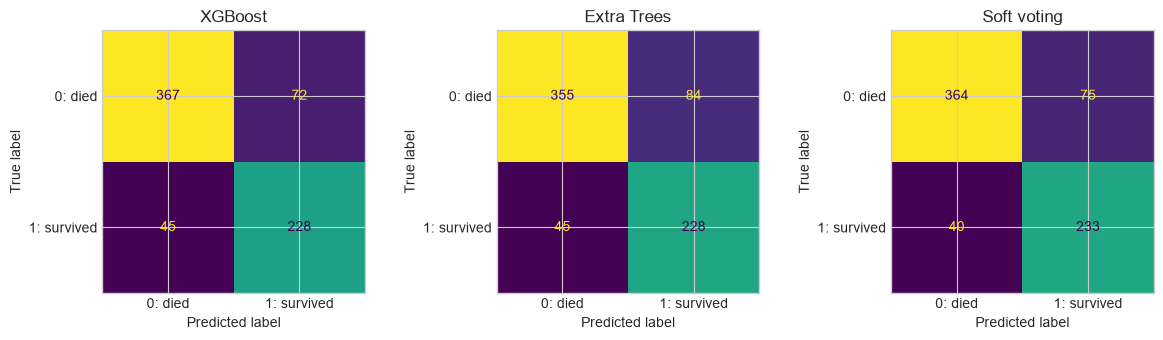

In [161]:
# モデル名と「OOF確率・採用設定」を対応させる辞書
model_results = {
    "XGBoost": (xgb_oof_probability, xgb_choice),
    "Extra Trees": (extra_oof_probability, extra_choice),
    "Soft voting": (ensemble_oof_probability, ensemble_choice),
}

# 全体指標とfold別F1を保存する空のリスト
overall_rows = []
fold_rows = []

# 3候補を1つずつ同じ方法で集計する
for model_name, (probability, choice) in model_results.items():
    # 全712件のOOF予測に対するF1・Precision・Recall
    row = metrics_from_probability(y, probability, choice["threshold"])
    row["model"] = model_name
    overall_rows.append(row)

    # fold 1〜5を個別に採点し、分割による性能のばらつきを見る
    for fold in range(1, N_SPLITS + 1):
        mask = fold_id == fold
        fold_rows.append({
            "model": model_name,
            "fold": fold,
            "f1": f1_score(y[mask], probability[mask] >= choice["threshold"]),
        })

# 全体指標を、1行1モデルの表に変換する
overall_table = pd.DataFrame(overall_rows).set_index("model")

# pivotで、モデルを行・fold番号を列に並べ替える
fold_table = pd.DataFrame(fold_rows).pivot(index="model", columns="fold", values="f1")

# meanは5foldの平均、stdはfold間のばらつき（標準偏差）
fold_table["mean"] = fold_table.mean(axis=1)
fold_table["std"] = fold_table.iloc[:, :N_SPLITS].std(axis=1)

display(overall_table.round(4))
display(fold_table.round(4))

# 3モデルの混同行列を横一列に表示する
# 混同行列は「実際の0/1」と「予測した0/1」の件数を4マスで示す
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, (model_name, (probability, choice)) in zip(axes, model_results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y,
        probability >= choice["threshold"],
        display_labels=["0: died", "1: survived"],
        colorbar=False,
        ax=ax,
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.show()


## 11. 学習データ全体で再学習し、テストを予測する

モデル・しきい値・混合比を決め終えたので、ここから初めてテスト特徴量をモデルへ入力します。学習ラベル712件をすべて使って2モデルを再学習します。

*〜 2モデルを学習データ全体でfitし、テスト179件の生存確率と0/1予測を作ります 〜*

**このセルで行うこと**

- **入力**：全712件の特徴量と正解、テスト179件の特徴量、CVで選んだ設定。
- **処理**：2モデルを全学習データで学習し、テストの確率を予測して0/1へ変換します。
- **出力**：3候補がテストで生存=1と予測した人数を表示します。

テストの正解はここでも使いません。`fit` は学習、`predict_proba` は生存確率の予測です。


In [162]:
# CVで設計を決め終えたため、提出用の新しいPipelineを作る
final_xgb_model = build_xgb_pipeline(X_xgb)
final_extra_model = build_extra_pipeline(X_extra)

# fit: 学習データ712件すべてを使って、最終モデルを学習する
final_xgb_model.fit(X_xgb, y)
final_extra_model.fit(X_extra, y)

# predict_probaの[:, 1]で、テスト179件の生存確率を取り出す
xgb_test_probability = final_xgb_model.predict_proba(X_test_xgb)[:, 1]
extra_test_probability = final_extra_model.predict_proba(X_test_extra)[:, 1]

# CVで決めた混合比をそのまま使い、テストのアンサンブル確率を作る
ensemble_test_probability = (
    ensemble_choice["xgb_weight"] * xgb_test_probability
    + (1.0 - ensemble_choice["xgb_weight"]) * extra_test_probability
)

# CVで決めた各しきい値を使い、生存確率を提出用の整数0/1へ変える
test_predictions = {
    "xgboost": (xgb_test_probability >= xgb_choice["threshold"]).astype(int),
    "extra_trees": (extra_test_probability >= extra_choice["threshold"]).astype(int),
    "soft_voting": (ensemble_test_probability >= ensemble_choice["threshold"]).astype(int),
}

# sumすると、各候補が生存=1と予測した人数を確認できる
print({name: int(prediction.sum()) for name, prediction in test_predictions.items()})


{'xgboost': 70, 'extra_trees': 78, 'soft_voting': 72}


## 12. 提出CSVを3個まで保存し、形式を検査する

3つのCSVはいずれもモデルの予測値だけから作ります。最終的に提出する数は規約どおり最大3個です。

*〜 PassengerIdと0/1予測だけを保存し、179件・重複なし・ID一致を自動検査します 〜*

**このセルで行うこと**

- **入力**：テストの `PassengerId` と3候補の0/1予測。
- **処理**：提出表を作り、列名・行数・ID・予測値を検査してCSVへ保存します。
- **出力**：`outputs` フォルダへ3個のCSVを作り、各ファイルの検査結果を表示します。

保存後にもう一度CSVを読み直すことで、メモリ上ではなく実際の提出ファイルも正しいことを確認します。


In [163]:
def make_and_validate_submission(prediction: np.ndarray) -> pd.DataFrame:
    """予測配列から提出表を作り、規定の形式か検査する。"""

    # テストCSVのPassengerIdを順番どおり使い、予測を整数へ変換する
    submission = pd.DataFrame({
        ID_COLUMN: test[ID_COLUMN].to_numpy(),
        TARGET: np.asarray(prediction, dtype=int),
    })

    # 列名と列順がPassengerId, Survivedになっているか
    assert submission.columns.tolist() == [ID_COLUMN, TARGET]

    # テスト全179件が過不足なくあるか
    assert len(submission) == len(test) == 179

    # IDが重複せず、テストCSVと同じ順番・同じ値か
    assert submission[ID_COLUMN].is_unique
    assert submission[ID_COLUMN].equals(test[ID_COLUMN])

    # 予測が整数の0または1だけか
    assert set(submission[TARGET].unique()) <= {0, 1}
    assert pd.api.types.is_integer_dtype(submission[TARGET])
    return submission


# outputsフォルダがなければ作る。すでにあってもexist_ok=Trueなら停止しない
OUTPUT_DIR.mkdir(exist_ok=True)

# 保存したモデル名とパスを記録する辞書
submission_paths = {}

# 3候補を1つずつ検査してCSVへ保存する
for model_name, prediction in test_predictions.items():
    submission = make_and_validate_submission(prediction)
    path = OUTPUT_DIR / f"submission_{model_name}.csv"
    # index=Falseにより、不要な0,1,2,...の行番号列を保存しない
    submission.to_csv(path, index=False)
    submission_paths[model_name] = path

# レギュレーションの最大3個を超えていないか確認する
assert len(submission_paths) <= 3

# 保存したCSVを読み直し、実ファイルも同じ検査に合格するか確認する
for model_name, path in submission_paths.items():
    reloaded = pd.read_csv(path)
    make_and_validate_submission(reloaded[TARGET].to_numpy())
    print(f"OK: {model_name:12s} -> {path} ({len(reloaded)} rows)")


OK: xgboost      -> outputs/submission_xgboost.csv (179 rows)
OK: extra_trees  -> outputs/submission_extra_trees.csv (179 rows)
OK: soft_voting  -> outputs/submission_soft_voting.csv (179 rows)


*〜 公開・説明用に、採用設定、CV F1、テストで1と予測した件数を一覧化します 〜*

**このセルで行うこと**

- **入力**：CV結果、テスト予測、保存先。
- **処理**：発表時に説明しやすい1枚の表へまとめます。
- **出力**：各モデルのしきい値、OOF指標、生存予測人数、CSV名と、アンサンブル重みを表示します。

この表のF1は学習データ内のOOF F1です。テストの正解が未知なので、テストF1ではありません。


In [164]:
# CV指標4列をコピーし、説明用の表の土台にする
submission_summary = overall_table[["threshold", "f1", "precision", "recall"]].copy()

# テスト179件のうち、生存=1と予測した人数を追加する
submission_summary["predicted_survivors_in_test"] = [
    int(test_predictions["xgboost"].sum()),
    int(test_predictions["extra_trees"].sum()),
    int(test_predictions["soft_voting"].sum()),
]

# 対応する提出CSVのファイル名を追加する
submission_summary["file"] = [
    str(submission_paths["xgboost"]),
    str(submission_paths["extra_trees"]),
    str(submission_paths["soft_voting"]),
]

# 小数第4位までに丸めて表示する
display(submission_summary.round(4))

# soft votingで採用したXGBoostの割合も表示する
print(f"Soft voting XGBoost weight: {ensemble_choice['xgb_weight']:.2f}")


,threshold,f1,precision,recall,predicted_survivors_in_test,file
model,,,,,,
XGBoost,0.35,0.7958,0.7600,0.8352,70,outputs/submission_xgboost.csv
Extra Trees,0.48,0.7795,0.7308,0.8352,78,outputs/submission_extra_trees.csv
Soft voting,0.41,0.8021,0.7565,0.8535,72,outputs/submission_soft_voting.csv


Soft voting XGBoost weight: 0.50


## 13. モデルが重視した特徴量を確認する

XGBoostのfeature importanceは、モデル内部で分岐に使われた重要度です。因果関係を表すものではありませんが、公開時にモデルの挙動を説明する手がかりになります。

*〜 学習済みXGBoostの上位15特徴量を表示します 〜*

**このセルで行うこと**

- **入力**：学習済みXGBoost Pipeline。
- **処理**：前処理後の列名とモデル内部の重要度を対応させ、上位15個を選びます。
- **出力**：重要度の表と横棒グラフを表示します。

重要度は「モデルが予測でよく利用した度合い」の目安です。「生存の原因」を証明する値ではありません。


,importance
categorical__Title_Mr,0.260446
categorical__Sex_male,0.147551
categorical__Sex_female,0.126605
numeric__Pclass,0.068485
numeric__FamilySize,0.045736
numeric__CabinCount,0.041384
numeric__CabinKnown,0.039424
categorical__Title_Master,0.023174
numeric__SibSp,0.019752
numeric__FarePerPerson,0.019381


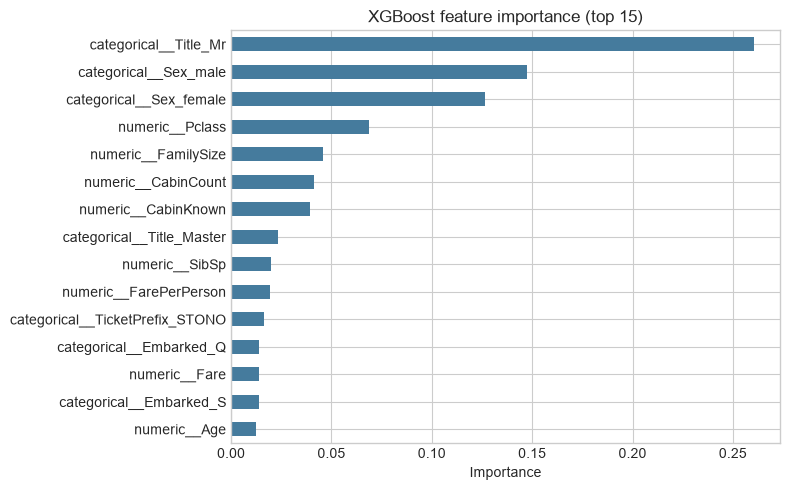

In [165]:
# 前処理によってOne-hot化された後の、実際の特徴量名を取得する
feature_names = final_xgb_model.named_steps["preprocess"].get_feature_names_out()

# XGBoost内部の重要度と特徴量名を対応させ、重要な順に上位15個を選ぶ
feature_importance = pd.Series(
    final_xgb_model.named_steps["model"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False).head(15)

# 重要度を数値表として表示する
display(feature_importance.rename("importance").to_frame())

# barh: 横向き棒グラフ。sort_valuesで重要度が高い特徴を上側にする
feature_importance.sort_values().plot.barh(figsize=(8, 5), color="#457b9d")
plt.title("XGBoost feature importance (top 15)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 14. 提出前チェックリスト

- [x] 外部データ・外部の正解ラベル・LLM分類を使っていない
- [x] 前処理は各CV学習foldだけでfitした
- [x] テストデータをモデル・しきい値・混合比の選択に使っていない
- [x] seed、目的変数、CV、評価指標、特徴量、ハイパーパラメータを明記した
- [x] 提出候補は最大3個で、すべてモデル予測から作成した
- [x] CSVは `PassengerId, Survived` の2列、179件、ID重複なし、予測は整数0/1

次に試す改善案は、次章に優先度・狙い・注意点付きでまとめています。


## 15. さらに精度を上げるために試す工夫

改善案は、**テストデータの正解を見ず、学習データ内のOOF F1平均とばらつきで採否を決める**ことが前提です。1回の最高値だけでなく、複数seedで再現するかも確認してください。

### おすすめの実施順序

| 優先度 | 試す工夫 | 期待する効果 | 実装・リーク上の注意 |
| ---: | --- | --- | --- |
| 1 | **複数seedのRepeated CV** | 1つの分割だけに良い設定を避け、改善が安定しているか確認できる | seedごとの平均F1と標準偏差を比較する。最高seedだけを選ばない |
| 1 | **RandomizedSearchCVでハイパーパラメータ探索** | 木の深さ、学習率、葉の最小件数などを手作業より広く比較できる | `Pipeline` 全体を探索し、`scoring="f1"` を使う。探索に使ったCVの最高値は楽観的なので別seedでも再確認する |
| 1 | **安全な特徴量を1個ずつ追加** | 年齢層、運賃帯、家族規模の非線形な差を表現できる | `AgeBand`、`FareBand`の境界をデータから学ぶなら、`KBinsDiscretizer`等をPipeline内でfitする |
| 2 | **OOF誤分類の分析** | False Positive/False Negativeが多い層を見つけ、一般化できる特徴量を考えられる | OOF行だけを分析し、テスト予測を人手で書き換えない。個人専用ルールを作らない |
| 2 | **学習fold内の頻度encoding** | `TicketGroup`や`FamilyKey`の「同じ値が何人いるか」を数値化できる | 全trainやtestを先に数えると検証情報が漏れる。必ず各foldの学習部分だけでfitするカスタムTransformerにする |
| 2 | **確率calibration** | 2モデルの確率尺度をそろえ、soft votingを安定させられる可能性がある | `CalibratedClassifierCV`も学習fold内だけでfitする。小データでは校正用データ不足に注意 |
| 2 | **複数seedモデルの確率平均** | 同じモデルでも木や分割の乱数によるばらつきを平均できる | 各モデルは配布trainだけから学習する。最終的な提出候補数が3個以内か確認する |
| 3 | **CatBoost / LightGBMを比較** | CatBoostはカテゴリを直接扱え、LightGBMは別方式のGBDTとして多様性を増やせる | 外部学習済みモデルや外部データは使わず、配布trainから0から学習する。新しい依存関係が必要 |
| 3 | **OOF stacking** | 基本モデルのOOF確率から、組み合わせ方自体を学習できる | 712件では過学習しやすい。メタモデルの学習には必ずOOF予測を使い、testや同じ行を学習した予測を使わない |
| 確認用 | **StratifiedGroupKFold** | 同じ家族・チケットがtrainとvalidationへまたがらない厳しい条件で、未知グループへの頑健性を確認できる | 通常CVよりF1が下がる可能性がある。最終評価の分割条件は未知なので、モデル選択の補助指標として扱う |

### 具体的に追加しやすい特徴量候補

- `AgeBand`：子ども・若年・成人・高齢など。ただし境界をCV外の全データで最適化しない。
- `FareBand`：運賃の絶対値だけでなく、安い・中程度・高いという区分を追加する。
- `FamilySizeCategory`：1人、小家族、大人数のように家族人数をカテゴリ化する。
- `IsChild`：年齢がある一定未満かを0/1で表す。年齢欠損者の扱いも明記する。
- `Sex × Pclass`、`Title × Pclass`：性別・敬称と客室等級の組み合わせを明示する。
- `TicketGroupSize`、`FamilyGroupSize`：同じチケット・家族キーの人数。ただし集計器は各foldの学習部分だけでfitする。

### 改善を採用する判断基準

1. 同じ5fold・同じseedで、変更前よりOOF F1が上がるか確認する。
2. 複数seedでも平均F1が上がり、標準偏差が極端に増えていないか確認する。
3. Precisionだけ・Recallだけではなく、正式指標F1が改善しているか確認する。
4. 前処理・集計・しきい値の決定にvalidationやtestの答えが混ざっていないか確認する。
5. 改善が小さい場合は、仕組みが単純で説明しやすい方を選ぶ。

> **最初に試す推奨案：** まずRepeated CVで現在の `0.8021` が安定しているか確認し、次にXGBoostの `max_depth`・`min_child_weight`・`subsample` とExtra Treesの `min_samples_leaf`・`max_features` をRandomizedSearchCVで探索するのが安全です。その後、特徴量を1個ずつ追加して差を測ると、何が効いたか説明しやすくなります。


F1スコア: 0.7483 (正解数: 142/179件)


/Users/k-teppei/Library/CloudStorage/GoogleDrive-kawaguchi.teppei.kw0@g.ext.naist.jp/マイドライブ/MI Lab/python_seminar/lesson_8/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-teppei/Library/CloudStorage/GoogleDrive-kawaguchi.teppei.kw0@g.ext.naist.jp/マイドライブ/MI Lab/python_seminar/lesson_8/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20129 (\N{CJK UNIFIED IDEOGRAPH-4EA1}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-teppei/Library/CloudStorage/GoogleDrive-kawaguchi.teppei.kw0@g.ext.naist.jp/マイドライブ/MI Lab/python_seminar/lesson_8/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-teppei/Library/CloudStorage/GoogleDri

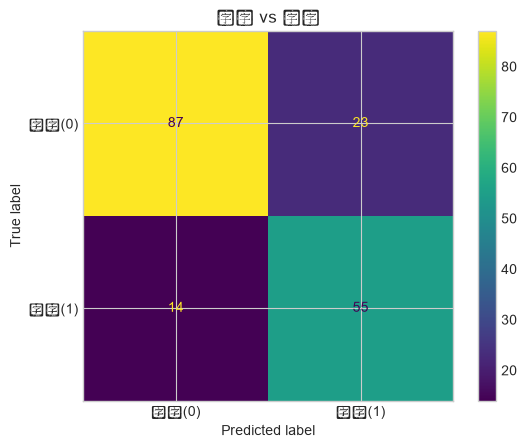

0.7482993197278912

In [170]:
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def result(y_pred, y_answer):
    # IDの過不足チェック
    missing = set(y_answer['PassengerId']) - set(y_pred['PassengerId'])
    extra = set(y_pred['PassengerId']) - set(y_answer['PassengerId'])
    if missing:
        print(f"⚠️ 未提出のID: {len(missing)}件")
    if extra:
        print(f"⚠️ 想定外のID: {len(extra)}件")

    # PassengerIdで突き合わせ
    merged = y_answer.merge(y_pred, on='PassengerId', suffixes=('_true', '_pred'))

    f1 = f1_score(merged['Survived_true'], merged['Survived_pred'])
    correct = (merged['Survived_true'] == merged['Survived_pred']).sum()
    print(f"F1スコア: {f1:.4f} (正解数: {correct}/{len(merged)}件)")
    
    cm = confusion_matrix(merged['Survived_true'], merged['Survived_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['死亡(0)', '生存(1)']).plot()
    plt.title('予測 vs 正解')
    plt.show()

    return f1

# --- 使う側 ---
y_answer = pd.read_csv('test_with_answer.csv')  # 自分だけが持つ模範解答

y_pred = pd.read_csv('submission_extra_trees.csv')
result(y_pred, y_answer)


F1スコア: 0.7482 (正解数: 144/179件)


/Users/k-teppei/Library/CloudStorage/GoogleDrive-kawaguchi.teppei.kw0@g.ext.naist.jp/マイドライブ/MI Lab/python_seminar/lesson_8/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-teppei/Library/CloudStorage/GoogleDrive-kawaguchi.teppei.kw0@g.ext.naist.jp/マイドライブ/MI Lab/python_seminar/lesson_8/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20129 (\N{CJK UNIFIED IDEOGRAPH-4EA1}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-teppei/Library/CloudStorage/GoogleDrive-kawaguchi.teppei.kw0@g.ext.naist.jp/マイドライブ/MI Lab/python_seminar/lesson_8/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-teppei/Library/CloudStorage/GoogleDri

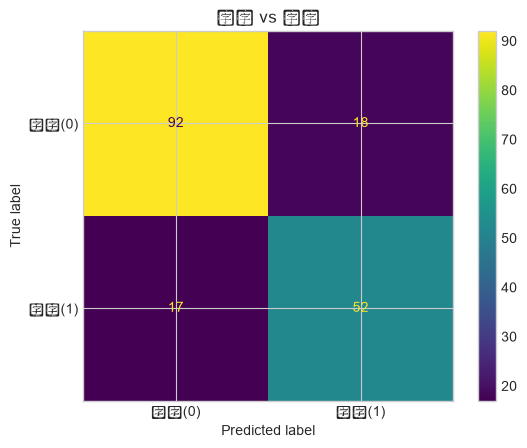

0.7482014388489209

In [171]:
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def result(y_pred, y_answer):
    # IDの過不足チェック
    missing = set(y_answer['PassengerId']) - set(y_pred['PassengerId'])
    extra = set(y_pred['PassengerId']) - set(y_answer['PassengerId'])
    if missing:
        print(f"⚠️ 未提出のID: {len(missing)}件")
    if extra:
        print(f"⚠️ 想定外のID: {len(extra)}件")

    # PassengerIdで突き合わせ
    merged = y_answer.merge(y_pred, on='PassengerId', suffixes=('_true', '_pred'))

    f1 = f1_score(merged['Survived_true'], merged['Survived_pred'])
    correct = (merged['Survived_true'] == merged['Survived_pred']).sum()
    print(f"F1スコア: {f1:.4f} (正解数: {correct}/{len(merged)}件)")
    
    cm = confusion_matrix(merged['Survived_true'], merged['Survived_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['死亡(0)', '生存(1)']).plot()
    plt.title('予測 vs 正解')
    plt.show()

    return f1

# --- 使う側 ---
y_answer = pd.read_csv('test_with_answer.csv')  # 自分だけが持つ模範解答

y_pred = pd.read_csv('submission_xgboost.csv')
result(y_pred, y_answer)

F1スコア: 0.7518 (正解数: 144/179件)


/Users/k-teppei/Library/CloudStorage/GoogleDrive-kawaguchi.teppei.kw0@g.ext.naist.jp/マイドライブ/MI Lab/python_seminar/lesson_8/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27515 (\N{CJK UNIFIED IDEOGRAPH-6B7B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-teppei/Library/CloudStorage/GoogleDrive-kawaguchi.teppei.kw0@g.ext.naist.jp/マイドライブ/MI Lab/python_seminar/lesson_8/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20129 (\N{CJK UNIFIED IDEOGRAPH-4EA1}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-teppei/Library/CloudStorage/GoogleDrive-kawaguchi.teppei.kw0@g.ext.naist.jp/マイドライブ/MI Lab/python_seminar/lesson_8/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/k-teppei/Library/CloudStorage/GoogleDri

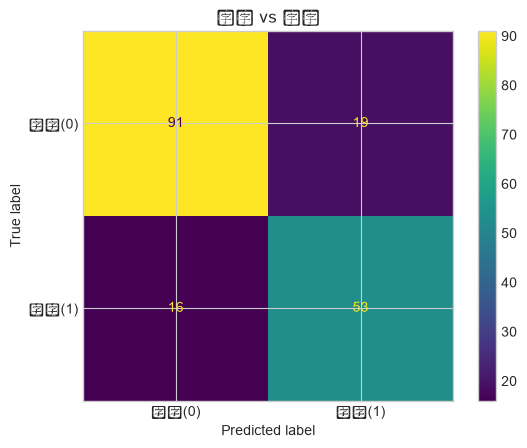

0.75177304964539

In [172]:
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def result(y_pred, y_answer):
    # IDの過不足チェック
    missing = set(y_answer['PassengerId']) - set(y_pred['PassengerId'])
    extra = set(y_pred['PassengerId']) - set(y_answer['PassengerId'])
    if missing:
        print(f"⚠️ 未提出のID: {len(missing)}件")
    if extra:
        print(f"⚠️ 想定外のID: {len(extra)}件")

    # PassengerIdで突き合わせ
    merged = y_answer.merge(y_pred, on='PassengerId', suffixes=('_true', '_pred'))

    f1 = f1_score(merged['Survived_true'], merged['Survived_pred'])
    correct = (merged['Survived_true'] == merged['Survived_pred']).sum()
    print(f"F1スコア: {f1:.4f} (正解数: {correct}/{len(merged)}件)")
    
    cm = confusion_matrix(merged['Survived_true'], merged['Survived_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['死亡(0)', '生存(1)']).plot()
    plt.title('予測 vs 正解')
    plt.show()

    return f1

# --- 使う側 ---
y_answer = pd.read_csv('test_with_answer.csv')  # 自分だけが持つ模範解答

y_pred = pd.read_csv('submission_soft_voting.csv')
result(y_pred, y_answer)